In [39]:
!nvidia-smi

Wed Mar 18 20:53:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P0             29W /   70W |     381MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torch.optim.optimizer import Optimizer
import matplotlib.pyplot as plt
import time
import pandas as pd

In [41]:
"""
HN_Adam: Hybrid and Adaptive Norming of Adam with AMSGrad — The Modified Algorithm

Implements Algorithm 2, Section 5 from:
    Reyad, M., Sarhan, A. & Arafa, M. "A modified Adam algorithm for deep
    neural network optimization." Neural Comput & Applic 35, 17095-17112 (2023).
    https://doi.org/10.1007/s00521-023-08568-z
"""

class HN_Adam(optim.Optimizer):
    r"""HN_Adam optimizer (Algorithm 2).

    Combines an adaptive norm technique with a hybrid switching mechanism
    between standard Adam and AMSGrad.  The letters "H" and "N" refer to the
    hybrid mechanism and the adaptive norm, respectively.

    Args:
        params (iterable): iterable of parameters to optimize or dicts
            defining parameter groups.
        lr (float): learning rate, step size :math:`\eta` (default: 1e-3).
        betas (Tuple[float, float]): coefficients :math:`(\beta_1, \beta_2)`
            for the exponential moving averages of the gradient and its
            powered absolute value (default: (0.9, 0.999)).
        eps (float): term added to the denominator for numerical stability
            :math:`\epsilon` (default: 1e-8).
        lambda_0 (float or None): initial threshold value of the norm
            :math:`\Lambda_{t_0}`.  When ``None`` it is drawn uniformly from
            [2, 4] as recommended in the paper (default: None).
    """

    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8,
                 lambda_0=None):
        # ---- validate hyper-parameters ----
        if lr < 0.0:
            raise ValueError(f"Invalid learning rate: {lr}")
        if eps < 0.0:
            raise ValueError(f"Invalid epsilon value: {eps}")
        if not 0.0 <= betas[0] < 1.0:
            raise ValueError(f"Invalid beta parameter at index 0: {betas[0]}")
        if not 0.0 <= betas[1] < 1.0:
            raise ValueError(f"Invalid beta parameter at index 1: {betas[1]}")

        # Require (Sec. 5): Λₜ₀ is randomly chosen in [2, 4]
        if lambda_0 is None:
            lambda_0 = 2.0 + 2.0 * torch.rand(1).item()  # uniform in [2, 4]
        if lambda_0 <= 0.0:
            raise ValueError(f"Invalid lambda_0 value: {lambda_0}, must be > 0")

        defaults = dict(lr=lr, betas=betas, eps=eps, lambda_0=lambda_0)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        r"""Perform a single optimisation step (Algorithm 2).

        Args:
            closure (callable, optional): a closure that re-evaluates the model
                and returns the loss.

        Returns:
            loss value (if *closure* was supplied).
        """
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        # ---- Algorithm 2: For all t = 1, …, T do ----
        for group in self.param_groups:
            lr = group['lr']
            beta1, beta2 = group['betas']
            eps = group['eps']
            lambda_0 = group['lambda_0']

            for p in group['params']:
                if p.grad is None:
                    continue

                # Step 5:  gₜ ← ∇ loss w.r.t. θₜ₋₁   //  f'(θₜ₋₁)
                grad = p.grad
                if grad.is_sparse:
                    raise RuntimeError(
                        "HN_Adam does not support sparse gradients")

                state = self.state[p]

                # ---- Initialize: m₀=0, v₀=0, amsgrad=False, v̂₍₀₎=0 ----
                if len(state) == 0:
                    state['step'] = 0
                    state['m'] = torch.zeros_like(
                        p, memory_format=torch.preserve_format)
                    state['v'] = torch.zeros_like(
                        p, memory_format=torch.preserve_format)
                    state['v_hat'] = torch.zeros_like(
                        p, memory_format=torch.preserve_format)

                m = state['m']
                v = state['v']
                v_hat = state['v_hat']
                state['step'] += 1

                # Save mₜ₋₁ before the in-place update
                m_prev = m.clone()

                # Step 6:  mₜ ← β₁·mₜ₋₁ + (1 − β₁)·gₜ        // moving average
                m.mul_(beta1).add_(grad, alpha=1.0 - beta1)

                # Step 7:  m_max ← Max(mₜ₋₁ , |gₜ|)
                abs_grad = grad.abs()
                m_max = torch.max(m_prev, abs_grad)
                # Clamp to avoid division by zero when both are zero
                m_max = m_max.clamp(min=eps)

                # Step 8:  Λ(t) ← Λₜ₀ − mₜ₋₁ / m_max            (Eq. 20)
                lambda_t = lambda_0 - m_prev / m_max
                # Clamp to a safe range to prevent extreme exponents
                lambda_t = lambda_t.clamp(min=1.0, max=10.0)

                # Step 9:  vₜ ← β₂·vₜ₋₁ + (1 − β₂)·|gₜ|^{Λ(t)}
                abs_grad_powered = torch.pow(abs_grad + eps, lambda_t)
                v.mul_(beta2).add_(abs_grad_powered, alpha=1.0 - beta2)

                # Precompute 1 / Λ(t) for the denominator exponent
                inv_lambda = 1.0 / lambda_t

                # Step 10: If Λ(t) < 2  →  switch between Adam and AMSGrad
                amsgrad_mask = lambda_t < 2.0

                # Step 12: v̂₍ₜ₎ ← Max(v̂₍ₜ₋₁₎, vₜ)  (AMSGrad branch only)
                v_hat_candidate = torch.max(v_hat, v)
                v_hat.copy_(torch.where(amsgrad_mask, v_hat_candidate, v_hat))

                # Step 13 (AMSGrad branch):
                #   θₜ ← θₜ₋₁ − η · mₜ / ( v̂₍ₜ₎^{1/Λ(t)} + ε )
                denom_amsgrad = torch.pow(
                    v_hat_candidate.clamp(min=0.0), inv_lambda) + eps

                # Step 16 (Adam branch):
                #   θₜ ← θₜ₋₁ − η · mₜ / ( vₜ^{1/Λ(t)} + ε )
                denom_adam = torch.pow(
                    v.clamp(min=0.0), inv_lambda) + eps

                # Element-wise selection of the correct denominator
                denom = torch.where(amsgrad_mask, denom_amsgrad, denom_adam)

                # Apply parameter update:
                #   θₜ ← θₜ₋₁ − η · mₜ / denom
                p.addcdiv_(m, denom, value=-lr)

        # Step 18: return final parameter θ_T
        return loss

In [42]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        # Convolutional blocks (no padding)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=0)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=0)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=0)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=0)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Flatten layer
        self.flatten = nn.Flatten()
        
        # Fully connected layers
        self.fc1 = nn.Linear(64 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 256)
        self.fc4 = nn.Linear(256, 32)
        self.fc5 = nn.Linear(32, 10)
        
        # Activation and dropout
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.1)
        self.softmax = nn.Softmax(dim=1)
    
    def forward(self, x):
        # Conv block 1
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.pool1(x)
        
        # Conv block 2
        x = self.relu(self.conv3(x))
        x = self.relu(self.conv4(x))
        x = self.pool2(x)
        
        # Flatten
        x = self.flatten(x)
        
        # Fully connected layers
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.dropout(x)
        x = self.relu(self.fc4(x))
        x = self.dropout(x)
        x = self.softmax(self.fc5(x))
        
        return x

# Instantiate model and verify parameter count
model = CNN()
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")
assert total_params == 697034, f"Expected 697034 parameters, got {total_params}"

Total parameters: 697034


In [ ]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# MNIST in float32, normalized to [0, 1]
transform = transforms.ToTensor()
mnist_train = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

# 40k train, 10k validation, 10k test
train_subset = Subset(mnist_train, range(0, 40000))
val_subset = Subset(mnist_train, range(40000, 50000))
test_subset = Subset(mnist_train, range(50000, 60000))

batch_size = 128
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

print(f"Train samples: {len(train_subset)}")
print(f"Validation samples: {len(val_subset)}")
print(f"Test samples: {len(test_subset)}")

# Hyperparameters
num_epochs = 20
lr = 0.001
beta1 = 0.9
beta2 = 0.999
eps = 1e-8

# Loss function
criterion = nn.CrossEntropyLoss()

# Dictionary to store results
results = {
	'HN_Adam': {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'time': 0, 'min_train_loss': 0, 'val_final_acc': 0, 'test_acc': 0},
	'Adam': {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'time': 0, 'min_train_loss': 0, 'val_final_acc': 0, 'test_acc': 0},
	'AMSGrad': {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'time': 0, 'min_train_loss': 0, 'val_final_acc': 0, 'test_acc': 0},
	'SGD': {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'time': 0, 'min_train_loss': 0, 'val_final_acc': 0, 'test_acc': 0}
}

def evaluate(model, loader, device):
	model.eval()
	total_loss = 0.0
	correct = 0
	total = 0
	with torch.no_grad():
		for data, target in loader:
			data, target = data.to(device), target.to(device)
			output = model(data)
			loss = criterion(output, target)
			total_loss += loss.item()
			_, predicted = torch.max(output.data, 1)
			total += target.size(0)
			correct += (predicted == target).sum().item()
	return total_loss / len(loader), correct / total

# Training function
def train_and_evaluate(model, train_loader, val_loader, test_loader, optimizer_class, optimizer_kwargs, device, num_epochs=20):
	model = model.to(device)
	optimizer = optimizer_class(model.parameters(), **optimizer_kwargs)

	train_losses, train_accs = [], []
	val_losses, val_accs = [], []

	start_time = time.time()

	for epoch in range(num_epochs):
		# Training phase
		model.train()
		epoch_loss = 0
		correct = 0
		total = 0

		for data, target in train_loader:
			data, target = data.to(device), target.to(device)

			optimizer.zero_grad()
			output = model(data)
			loss = criterion(output, target)
			loss.backward()
			optimizer.step()

			epoch_loss += loss.item()
			_, predicted = torch.max(output.data, 1)
			total += target.size(0)
			correct += (predicted == target).sum().item()

		avg_train_loss = epoch_loss / len(train_loader)
		train_acc = correct / total
		train_losses.append(avg_train_loss)
		train_accs.append(train_acc)

		elapsed_time = time.time() - start_time

		# Validation phase
		val_loss, val_acc = evaluate(model, val_loader, device)
		val_losses.append(val_loss)
		val_accs.append(val_acc)

		if (epoch + 1) % 5 == 0:
			print(
				f"Epoch {epoch+1}/{num_epochs}, "
				f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}, "
				f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
			)

	# Final validation phase (before test phase)
	val_final_loss, val_final_acc = evaluate(model, val_loader, device)

	# Test phase
	_, test_acc = evaluate(model, test_loader, device)

	min_train_loss = min(train_losses)

	return train_losses, train_accs, val_losses, val_accs, val_final_acc, test_acc, elapsed_time, min_train_loss

# Train with different optimizers
optimizers_config = {
	'HN_Adam': (HN_Adam, {'lr': lr, 'betas': (beta1, beta2), 'eps': eps}),
	'Adam': (optim.Adam, {'lr': lr, 'betas': (beta1, beta2), 'eps': eps}),
	'AMSGrad': (optim.Adam, {'lr': lr, 'betas': (beta1, beta2), 'eps': eps, 'amsgrad': True}),
	'SGD': (optim.SGD, {'lr': lr})
}

for opt_name, (opt_class, opt_kwargs) in optimizers_config.items():
	print(f"\n{'='*50}")
	print(f"Training with {opt_name}")
	print(f"{'='*50}")

	model = CNN().to(device)
	train_loss, train_acc, val_loss, val_acc, val_final_acc, test_acc, elapsed_time, min_train_loss = train_and_evaluate(
		model, train_loader, val_loader, test_loader, opt_class, opt_kwargs, device, num_epochs
	)

	results[opt_name]['train_loss'] = train_loss
	results[opt_name]['train_acc'] = train_acc
	results[opt_name]['val_loss'] = val_loss
	results[opt_name]['val_acc'] = val_acc
	results[opt_name]['val_final_acc'] = val_final_acc
	results[opt_name]['test_acc'] = test_acc
	results[opt_name]['time'] = elapsed_time
	results[opt_name]['min_train_loss'] = min_train_loss

	print(
		f"{opt_name} - Val Accuracy: {val_final_acc:.4f}, "
		f"Test Accuracy: {test_acc:.4f}, Training Time: {elapsed_time:.2f}s"
	)


Using device: cuda
Train samples: 40000
Validation samples: 10000
Test samples: 10000

Training with HN_Adam
Epoch 5/50, Train Loss: 2.3015, Train Acc: 0.1141, Val Loss: 2.3026, Val Acc: 0.1115
Epoch 10/50, Train Loss: 2.3015, Train Acc: 0.1141, Val Loss: 2.3025, Val Acc: 0.1115
Epoch 15/50, Train Loss: 2.3015, Train Acc: 0.1141, Val Loss: 2.3025, Val Acc: 0.1115
Epoch 20/50, Train Loss: 2.3015, Train Acc: 0.1141, Val Loss: 2.3025, Val Acc: 0.1115
Epoch 25/50, Train Loss: 2.3015, Train Acc: 0.1141, Val Loss: 2.3026, Val Acc: 0.1115
Epoch 30/50, Train Loss: 2.3015, Train Acc: 0.1141, Val Loss: 2.3026, Val Acc: 0.1115
Epoch 35/50, Train Loss: 2.3015, Train Acc: 0.1141, Val Loss: 2.3026, Val Acc: 0.1115
Epoch 40/50, Train Loss: 2.3014, Train Acc: 0.1141, Val Loss: 2.3026, Val Acc: 0.1115


: 

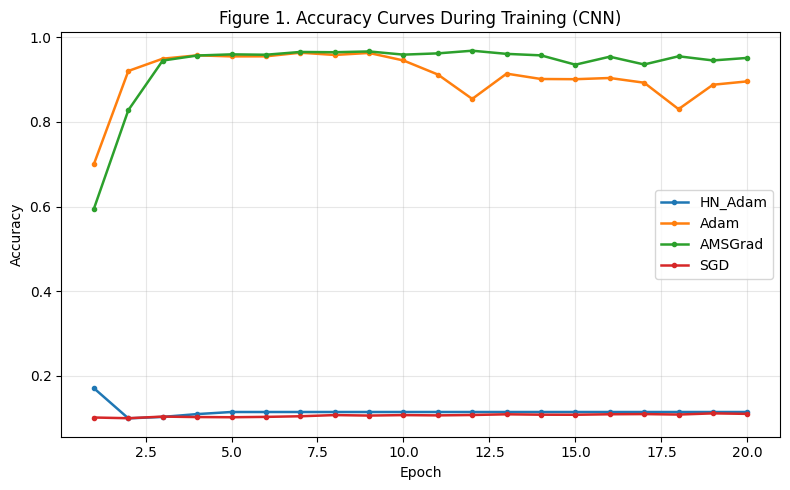

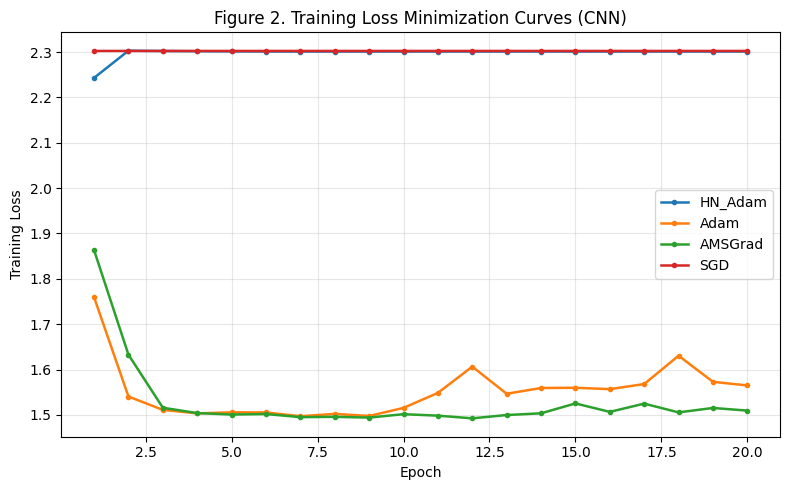

Table 1. Minimum Training Loss, Test Accuracy, and Training Time
Algorithm Min Training Loss Test Accuracy Training Time (s)
  HN_Adam          2.242937        0.1064            172.06
     Adam          1.497248        0.9336            158.51
  AMSGrad          1.492612        0.9606            158.22
      SGD          2.302325        0.1064            155.16


In [ ]:
# Order algorithms consistently with your experiment config
algorithms = list(optimizers_config.keys()) if "optimizers_config" in globals() else list(results.keys())

# ----------------------------
# Figure 1: Accuracy curves
# ----------------------------
plt.figure(figsize=(8, 5))
for alg in algorithms:
    acc_curve = results[alg]["train_acc"]  # accuracy tracked during training
    epochs = range(1, len(acc_curve) + 1)
    plt.plot(epochs, acc_curve, marker="o", linewidth=1.8, markersize=3, label=alg)

plt.title("Figure 1. Accuracy Curves During Training (CNN)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# Figure 2: Loss minimization curves
# ----------------------------
plt.figure(figsize=(8, 5))
for alg in algorithms:
    loss_curve = results[alg]["train_loss"]
    epochs = range(1, len(loss_curve) + 1)
    plt.plot(epochs, loss_curve, marker="o", linewidth=1.8, markersize=3, label=alg)

plt.title("Figure 2. Training Loss Minimization Curves (CNN)")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# Table 1: Summary metrics
# ----------------------------
table1 = pd.DataFrame(
    [
        {
            "Algorithm": alg,
            "Min Training Loss": results[alg]["min_train_loss"],
            "Test Accuracy": results[alg]["test_acc"],
            "Training Time (s)": results[alg]["time"],
        }
        for alg in algorithms
    ]
)

# Optional formatting for readability
table1["Min Training Loss"] = table1["Min Training Loss"].map(lambda x: f"{x:.6f}")
table1["Test Accuracy"] = table1["Test Accuracy"].map(lambda x: f"{x:.4f}")
table1["Training Time (s)"] = table1["Training Time (s)"].map(lambda x: f"{x:.2f}")

print("Table 1. Minimum Training Loss, Test Accuracy, and Training Time")
print(table1.to_string(index=False))